## Exploración

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("bank-full_limpio.csv", sep = ";")

### Estadisticas

In [2]:
df.info

<bound method DataFrame.info of        age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
...    ...           ...       ...        ...     ...      ...     ...  ...   
45206   51    technician   married   tertiary      no      825      no   no   
45207   71       retired  divorced    primary      no     1729      no   no   
45208   72       retired   married  secondary      no     5715      no   no   
45209   57   blue-collar   married  secondary      no      668      no   no   
45210   37  entrepreneur   married  secondary      no     2971      no   no   

         contact  d

In [3]:
df.describe()


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [4]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


In [5]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


In [6]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [7]:
df_numerico = df.select_dtypes(include=['float64', 'int64'])
df_numerico.head()

,age,balance,day,duration,campaign,pdays,previous
0,58,2143,5,261,1,-1,0
1,44,29,5,151,1,-1,0
2,33,2,5,76,1,-1,0
3,47,1506,5,92,1,-1,0
4,33,1,5,198,1,-1,0


### Histogramas

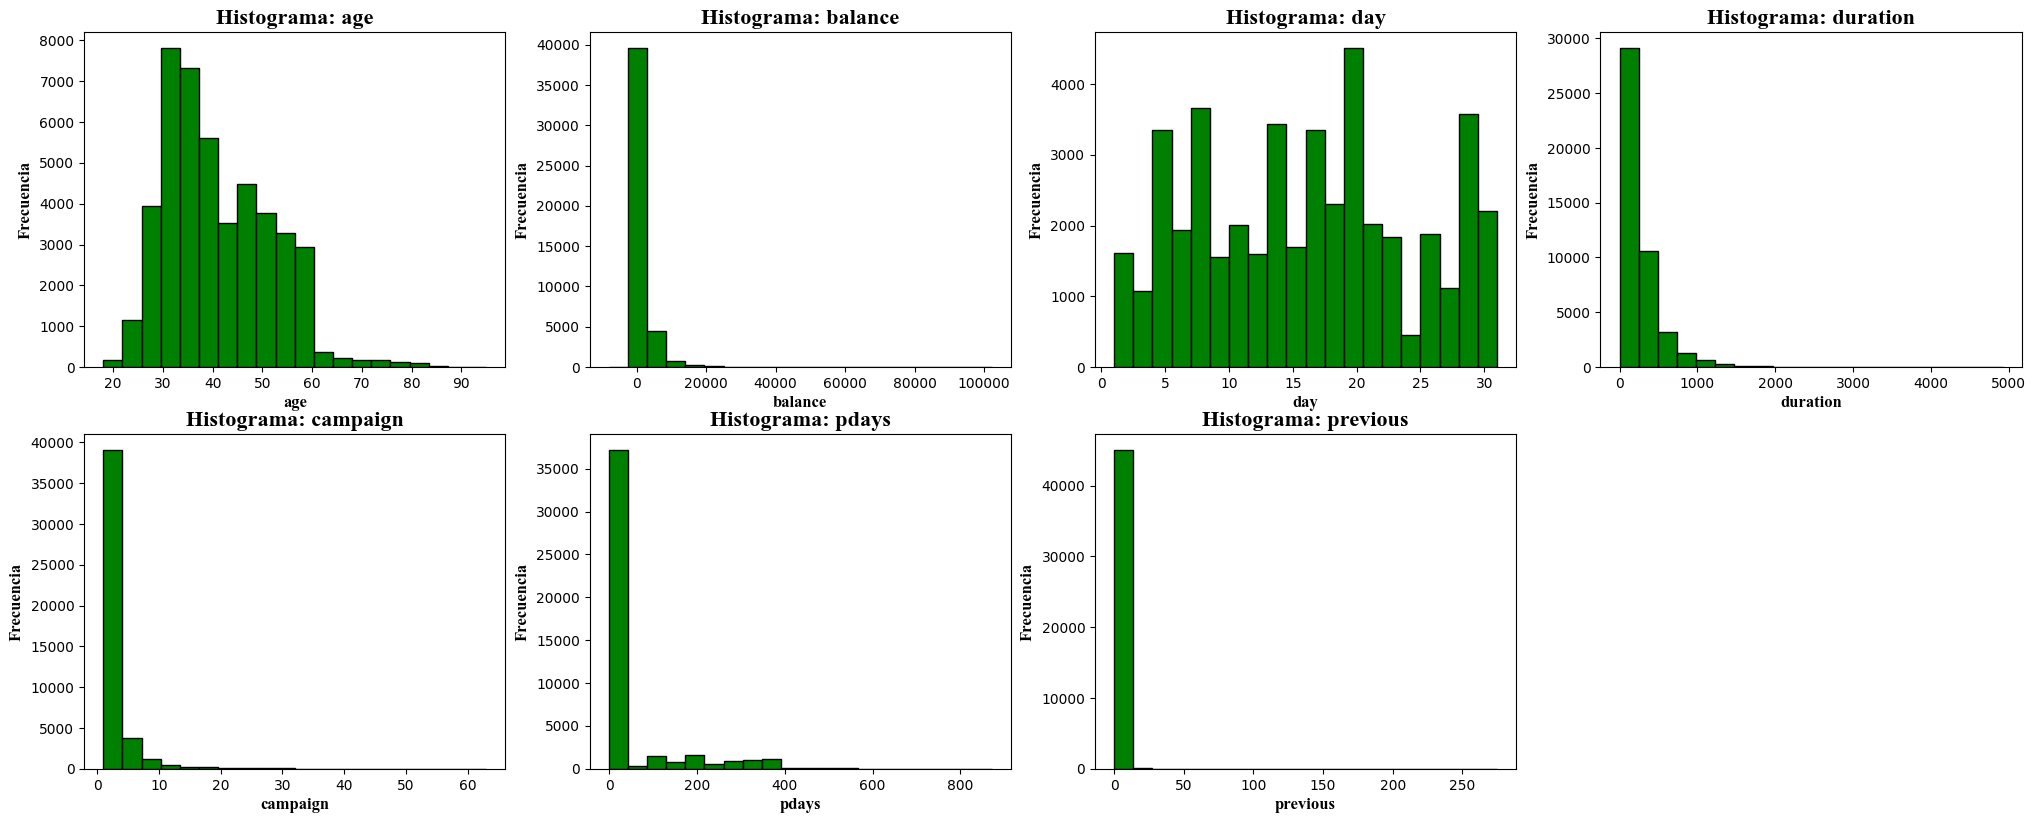

In [8]:
fig = plt.figure(figsize=(25, 20))
for i, column in enumerate(col for col in df_numerico.columns):
    ax = fig.add_subplot(4, 4, i+1)  
    ax.hist(df_numerico[column], bins=20, edgecolor='black', color = "green") 
    ax.set_title(f'Histograma: {column}', fontweight = "bold", fontname = "Times New Roman", fontsize = 16)
    ax.set_xlabel(column, fontweight = "bold", fontname = "Times New Roman", fontsize = 12)
    ax.set_ylabel('Frecuencia', fontweight = "bold", fontname = "Times New Roman", fontsize = 12)

### Diagramas de Caja

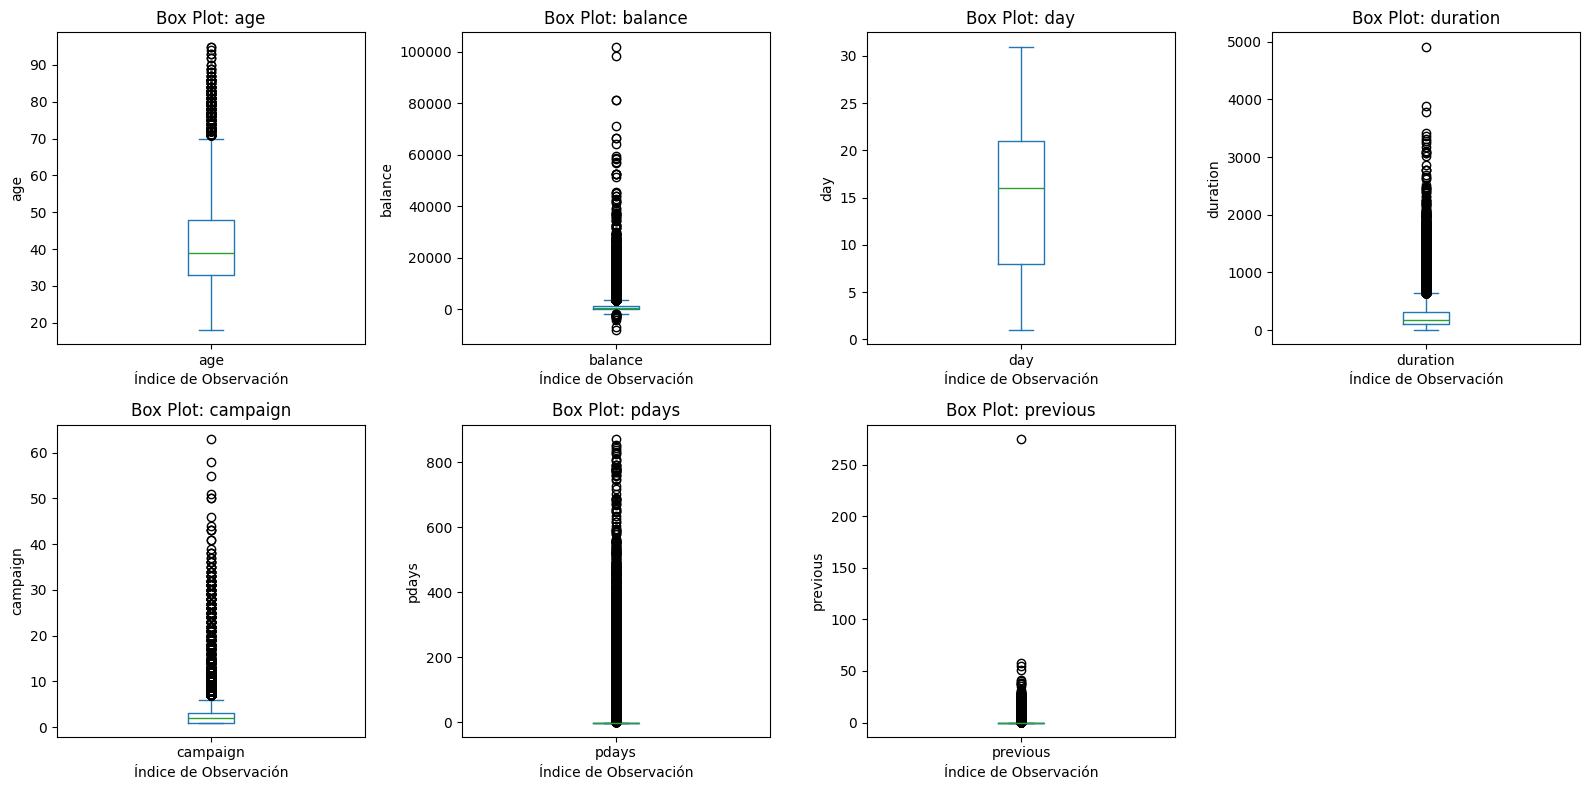

In [9]:
# Crear figura y ejes
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))

# Aplanar los ejes para iterar fácilmente
axes = axes.flatten()

# Recorrer las columnas numéricas y generar el boxplot en el subplot correspondiente
for i, column in enumerate(df_numerico.columns):
    df_numerico[column].plot(kind='box', ax=axes[i])
    axes[i].set_title(f'Box Plot: {column}')
    axes[i].set_xlabel('Índice de Observación')
    axes[i].set_ylabel(column)

# Ocultar el octavo gráfico (el sobrante)
fig.delaxes(axes[-1])

# Ajustar diseño para que no se sobrepongan las etiquetas
plt.tight_layout()
plt.show()

### Diagramas de Violin

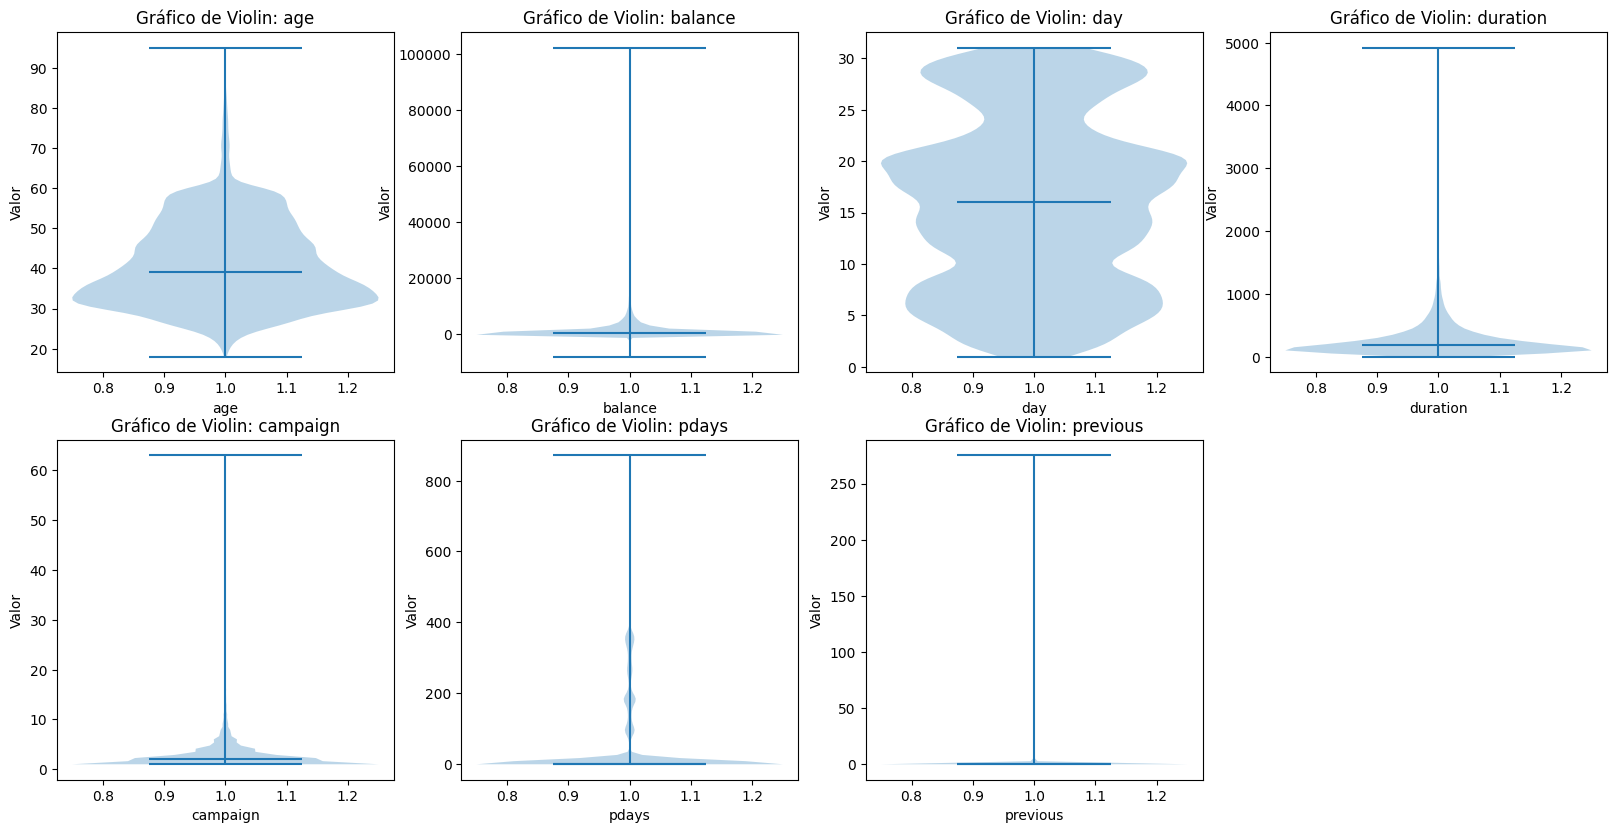

In [10]:
fig = plt.figure(figsize=(20, 15)) 

for i, column in enumerate(col for col in df_numerico.columns ):
    ax = fig.add_subplot(3, 4, i+1) 
    violins = ax.violinplot(df_numerico[column], showmeans=False, showmedians=True)
    ax.set_title(f'Gráfico de Violin: {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Valor')

### Correlación

<Axes: >

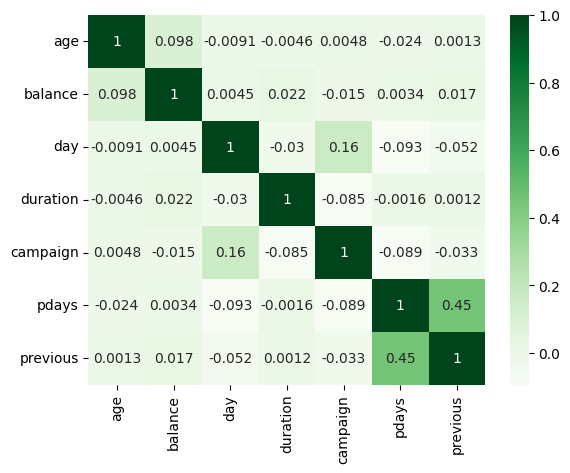

In [11]:
corr = df_numerico.corr()
sns.heatmap(corr, cmap="Greens", annot=True)

### Variable respuesta vs numéricas

C:\Users\Samyp\AppData\Local\Temp\ipykernel_18376\3150270934.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="y", y=var, data=df, jitter=0.2, palette="Greens", ax=axes[row, col])
C:\Users\Samyp\AppData\Local\Temp\ipykernel_18376\3150270934.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="y", y=var, data=df, jitter=0.2, palette="Greens", ax=axes[row, col])
C:\Users\Samyp\AppData\Local\Temp\ipykernel_18376\3150270934.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="y", y=var, data=df, jitter=0.2, palette="Greens", ax

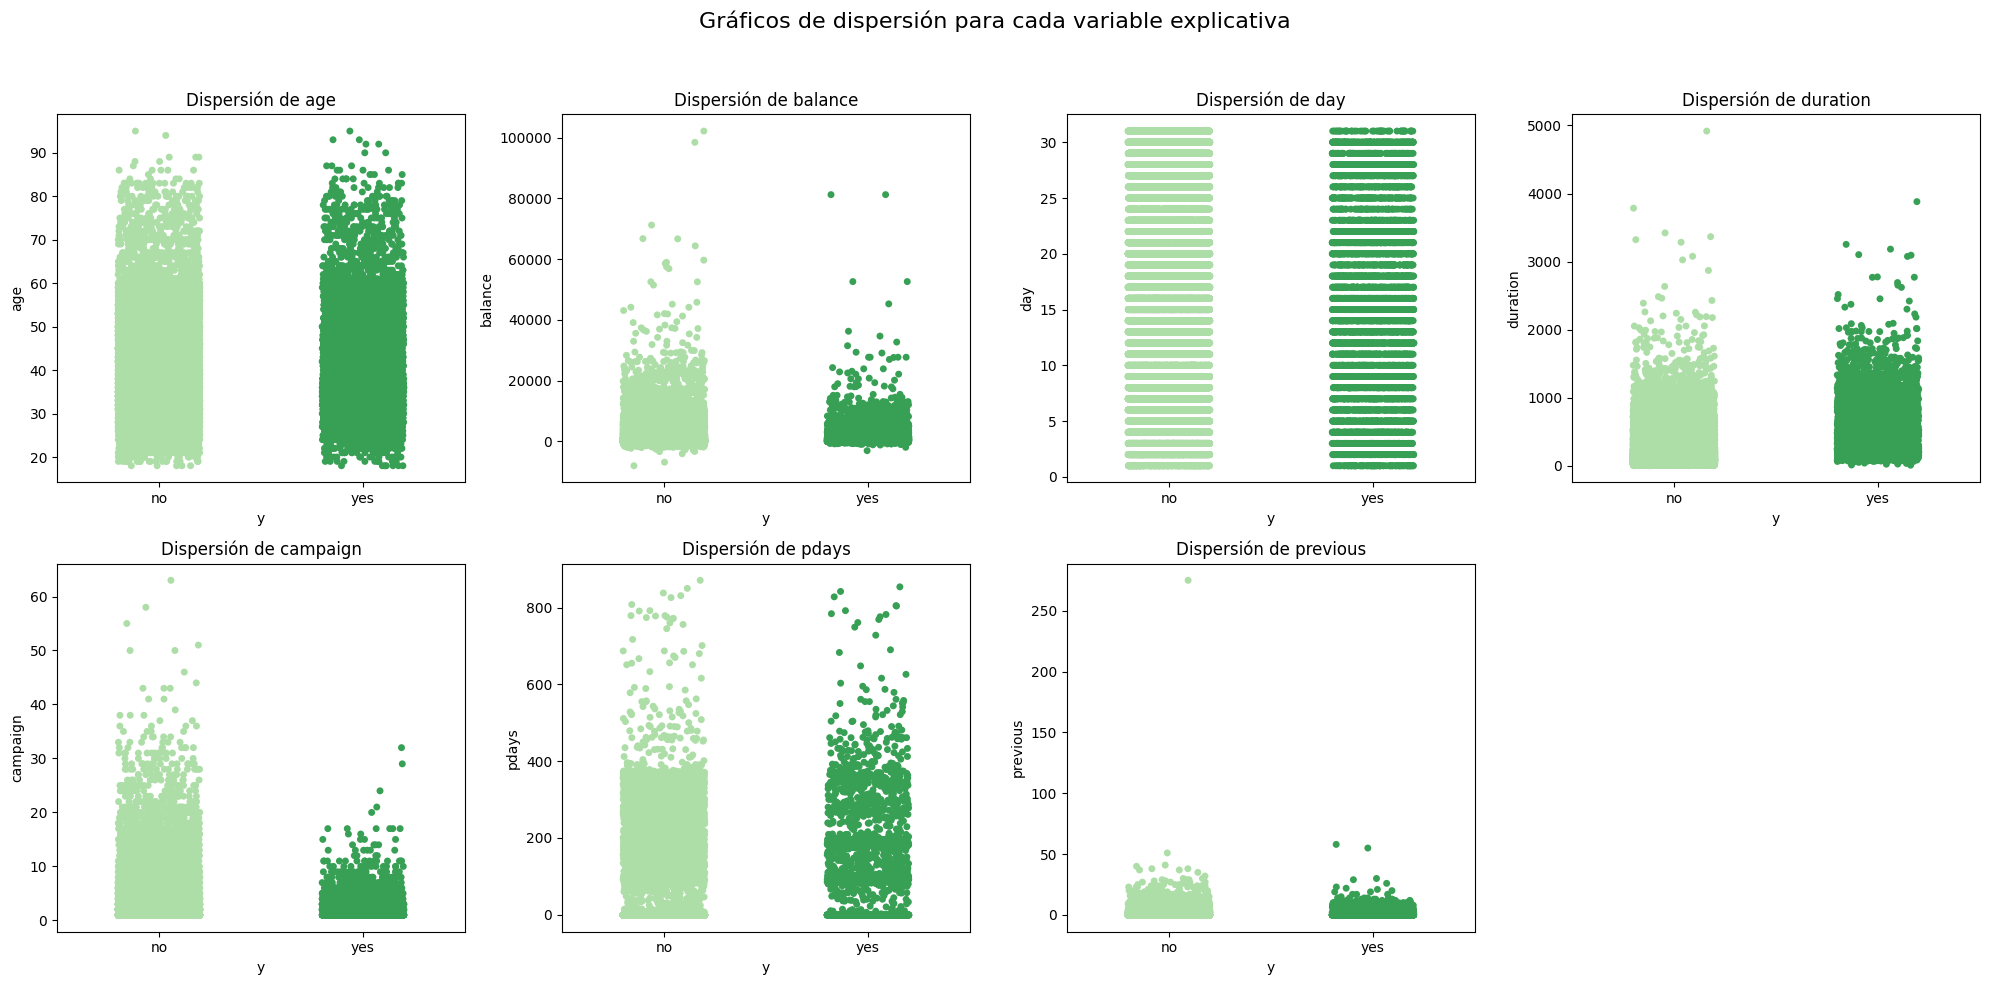

In [12]:
# Lista de variables explicativas
variables_explicativas = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]

# Crear figura y subplots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))  
fig.suptitle("Gráficos de dispersión para cada variable explicativa", fontsize=16)

# Crear gráficos para cada variable
for i, var in enumerate(variables_explicativas):
    row = i // 4  
    col = i % 4   
    sns.stripplot(x="y", y=var, data=df, jitter=0.2, palette="Greens", ax=axes[row, col])
    axes[row, col].set_title(f'Dispersión de {var}')

# Ocultar el último espacio vacío
axes[1, 3].axis('off')

# Ajustar el layout para evitar solapamientos
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 